# Fairness

Two questions hide under this word, and they need separating before anything useful can be said.

1. **Does the model work equally well for everyone?** A model with an average error of 5 years
   might have an error of 3 in one group and 12 in another. The average is real; so is the
   disparity, and the average conceals it.
2. **Was the model asked to predict the right thing?** This one is not about performance at all.
   A model can be accurate, calibrated, externally validated, and still entrench a harm — because
   the quantity it was trained to predict was a poor stand-in for the quantity anyone cared about.

The second question is the deeper one, and the clearest case study in the literature is not a brain
imaging study at all.

## The algorithm that was accurate and wrong

{cite:t}`obermeyer2019dissecting` examined a commercial risk-prediction algorithm used by US
health systems to select patients for "high-risk care management" programmes — extra nursing
attention, extra appointment slots, coordinated care. Patients above the 97th percentile of
predicted risk were enrolled automatically. Algorithms of this class are applied, by industry
estimates, to around 200 million people a year.

The algorithm was trained to predict **total health-care costs in the coming year**, from claims
data: demographics, insurance type, diagnoses, procedures, medications. It did **not** use race as
a feature.

It was also, on its own terms, a good model. At every level of predicted risk, Black and White
patients went on to incur about the same costs — the predictions were well calibrated, and
calibrated *equally within each racial group*.

And yet, **at the same risk score, Black patients were considerably sicker**: 26.3% more chronic
conditions (4.8 versus 3.8), worse blood pressure, worse diabetic control. The authors calculated
that removing the disparity would raise the share of Black patients receiving the extra help from
**17.7% to 46.5%**. The finding was not a quirk of one hospital: the algorithm's manufacturer
repeated the analysis on its own national database of **3.7 million** insured patients and
confirmed it.

### Why it happened

The mechanism is worth walking through slowly, because it is entirely mundane and that is the
point.

The health system wanted to find the patients with the greatest **need**. Need is not recorded in
a database. Cost is. So cost became the label.

But cost does not measure need — it measures **need that got treated**. And for reasons ranging
from transport and time off work to insurance, mistrust, and differential treatment by clinicians,
less money is spent on Black patients at the same level of illness: about **$1,801 less per year**
at an equal number of chronic conditions.

Now put the two facts together. If the model is calibrated on cost, and cost is systematically
lower for Black patients at equal illness, then equal predicted cost necessarily means *unequal
illness*. The disparity is not a bug in the fitting procedure. It is an algebraic consequence of
training a good model on a label with a group-dependent offset. The algorithm faithfully learned a
historical pattern of unequal treatment and re-expressed it as a prediction of unequal need.

### The fix, and what it tells us

The authors did not change the algorithm. They changed the label — training the identical
procedure to predict active chronic conditions instead of costs. That **roughly doubled** the share
of Black patients among those auto-enrolled, from 14.1% to 26.7%. A further variant, predicting an
index that combined health with cost, reduced their measure of bias — the excess chronic conditions
carried by Black patients at equal risk score — by **84%**.

```{margin} Read the numbers carefully
46.5% is a counterfactual: the composition if the health gap at a given score were closed
completely. The retrained model achieved about 27%. Both are reported in the paper; they answer
different questions, and they are routinely conflated.
```

### Why no amount of methodological rigour would have caught this

Everything this book has taught you was satisfied.

- Not overfitted: it held up out of sample, and was deployed at national scale.
- Not leaky: no implausible performance.
- Well calibrated on the quantity it predicted, and calibrated *equally* across racial groups.
- It did not even use the protected attribute.
- Its behaviour was reproduced in an independent national dataset of 3.7 million patients.

And here is the part worth sitting with: **even a textbook external validation would have passed
it**. Apply the model at a new hospital, compare predicted with actual costs, and it would predict
costs well there too — because it does predict costs well. Every validation available to you
validates the model against its label.

Cross-validation asks whether your estimate of $f$ generalizes to new draws from the same
distribution. External validation asks whether it transports to a new site. **Neither asks whether
$y$ was the right thing to predict** — and neither can, because the quantity actually of interest
was never measured. You cannot cross-validate against a variable that is not in your data.

This is what psychometricians call **construct validity**, and it is the part of measurement theory
that predictive modelling has been slowest to import. The diagnostic that did work is worth
memorizing, because it generalizes: **audit the model's output against an independently measured
proxy for the construct you actually care about, stratified by a group variable the model never
saw.** Not against its label. Against the thing you meant.

```{note}
The authors list the same failure mode elsewhere: hospital quality measured by readmission rates
penalizes hospitals serving poorer populations; credit scores predict outcomes shaped by
discrimination in employment; predictive policing predicts *recorded* crime, which reflects where
police already go; hiring algorithms predict supervisor ratings, which carry the biases of
supervisors.
```

## Does our model work equally well for everyone?

Back to the brain. The first fairness question — equal performance across groups — is one we can
actually run.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error

DATA_URL = "https://raw.githubusercontent.com/pni-lab/predmod_lecture/master/ex_data/IXI/ixi.csv"

ixi = pd.read_csv(DATA_URL).sample(frac=1, random_state=42).reset_index(drop=True)
TARGET = 'Age'
FEATURES = [c for c in ixi.columns if c.endswith('_volume')]

model = Pipeline([('standardize', StandardScaler()), ('regression', Ridge(alpha=100))])
ixi['predicted'] = cross_val_predict(model, X=ixi[FEATURES], y=ixi[TARGET], cv=KFold(5))
ixi['error'] = ixi['predicted'] - ixi[TARGET]

# head size is not recorded directly, so we use total cortical volume as a stand-in
ixi['head_size'] = pd.qcut(ixi[FEATURES].sum(axis=1), 3, labels=['small', 'medium', 'large'])

by_size = ixi.groupby('head_size', observed=True).apply(
    lambda g: pd.Series({'n': len(g),
                         'mean age': g[TARGET].mean(),
                         'MAE (years)': mean_absolute_error(g[TARGET], g['predicted']),
                         'mean signed error': g['error'].mean()}),
    include_groups=False)
by_size.round(2)

,n,mean age,MAE (years),mean signed error
head_size,,,,
small,213.0,60.54,9.74,-0.17
medium,212.0,51.99,10.14,-0.19
large,213.0,39.87,9.39,0.57


The audit comes back largely reassuring: the three groups' errors span three-quarters of a year
(9.4 to 10.1), with only a modest over-prediction in the large-volume group (+0.6 years). Report
that. A null result from a fairness audit is a finding, and a study that ran the analysis and found
little is more trustworthy than one that did not look.

But note why the second column has to be there, and then note what it does to the conclusion. The
groups differ enormously in mean age — 61, 52 and 40 years — because total cortical volume is
exactly the variable that [the previous page](validity.ipynb) showed to be entangled with both age
and the model's output. So this is not a clean test of "does the model work equally well for large
and small heads": the grouping variable is confounded with the target by construction, and any
result would have been hard to attribute. It is a reminder that a subgroup audit is only as
interpretable as the subgroups are comparable — which is why the variables worth auditing on
(sex, site, scanner) are the ones chosen at study design, not improvised from the features.

Our model does, at any rate, treat one group markedly worse than another. Just not this grouping.

## The disparity that is built into the method

There is a second, more systematic unfairness in our model, and it afflicts essentially every
brain-age model ever published.

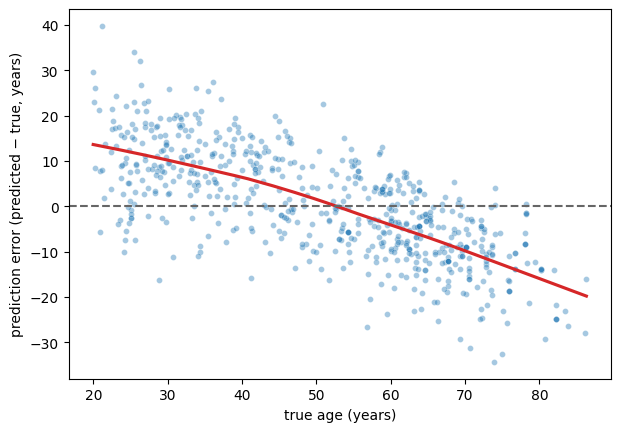

participants under 30 (n=104): predicted +10.5 years on average
participants over 70  (n=90): predicted -13.2 years on average


In [2]:
plt.figure(figsize=(7, 4.8))
sns.scatterplot(data=ixi, x=TARGET, y='error', alpha=0.4, s=18)
sns.regplot(data=ixi, x=TARGET, y='error', scatter=False, color='#d62728', lowess=True)
plt.axhline(0, color='0.4', ls='--')
plt.xlabel('true age (years)')
plt.ylabel('prediction error (predicted − true, years)')
plt.show()

young = ixi[ixi[TARGET] < 30]
old = ixi[ixi[TARGET] > 70]
print(f'participants under 30 (n={len(young)}): predicted {young["error"].mean():+.1f} years on average')
print(f'participants over 70  (n={len(old)}): predicted {old["error"].mean():+.1f} years on average')

The young are predicted too old; the old are predicted too young. This is **regression towards the
mean** — a mathematical consequence of any model that explains less than all of the variance,
which is to say, of every model. Shrinking predictions towards the training mean is exactly what
minimizes squared error, so the fitting procedure produces this on purpose.

It is also a fairness problem with teeth, because brain-age models are used by computing the
**brain-age gap**: predicted age minus chronological age, interpreted as "this brain looks older
than it should". Our model assigns a positive gap to almost everyone under 30 and a negative gap to
almost everyone over 70 — purely as an artefact of the regression, before any biology. If you then
correlate that gap with anything that varies with age — and most clinical variables do — you will
find associations that are entirely manufactured.

The brain-age literature has developed explicit corrections for this bias. The lesson for this book
is more general: **a systematic error that depends on the target, or on any variable correlated
with it, is a bias in every subgroup defined by that variable** — and the overall MAE will never
show it to you. Plot your errors against everything you have.

## Fairness measures, and why you cannot have all of them

For classification, several formal criteria compete:

- **Demographic parity**: the model flags the same proportion of each group.
- **Equalized odds**: true positive and false positive rates match across groups.
- **Calibration within groups**: among everyone given risk score 0.7, the same fraction in each
  group actually has the outcome.

Each sounds reasonable. They cannot in general be satisfied simultaneously: a well-known
impossibility result shows that whenever the base rate of the outcome differs between groups,
calibration and equal error rates are mathematically incompatible except in degenerate cases
{cite:p}`mehrabi2021survey`. This is not a gap waiting to be closed by a cleverer
algorithm. It means that **fairness is a choice among incompatible definitions**, and the choice
belongs to the people affected and to the people deploying the model, not to whoever writes the
loss function.

Notice how the Obermeyer algorithm sits in this frame: it satisfied calibration within groups
perfectly. That was not enough, and no rebalancing of the criteria would have helped, because the
problem lived one level up — in the label.

## What you can audit is what you recorded

Our dataset contains participant ID, age, and 68 volumes. That is all. We could not test the model
for sex differences even if we wanted to, because sex is not in the file — although the IXI cohort
does publish it. Nor site, nor scanner, nor education, nor anything else.

This is the most practical lesson of the chapter, and it is a study-design lesson rather than an
analysis one:

- **Record the variables you will need for the audit**, at collection time. Demographics, site,
  scanner, acquisition date, operator. You cannot add them later.
- **Report subgroup performance**, not just the average — and report the subgroup sizes, because a
  confidence interval around an MAE in a group of 20 is wide.
- **Interrogate the label** before the model. Ask what construct you actually care about, what you
  are able to measure, and by what mechanism the two could come apart for some group of people.
  Write the answer down in the paper.
- **Plot the errors against everything**, including the target.

:::{admonition} Exercise 6.7
:class: tip, dropdown
Download the IXI demographics, merge in sex, and repeat the subgroup analysis. Is the MAE
comparable for male and female participants? Then run the
[partial confounder test](validity.ipynb) with sex as the confounder. What is the difference
between these two analyses — what does each one tell you that the other does not?

:::{admonition} Solution
:class: note, dropdown
The subgroup analysis asks *does the model work equally well for these two groups*. The confounder
test asks *does the model's output depend on sex beyond what the sex–age relationship implies*.
A model can pass one and fail the other in either direction: equally accurate for both groups
while being partly a sex classifier, or unbiased in the conditional-independence sense while
performing much worse in the smaller group. They are different questions and you want both answers.
:::
:::

:::{admonition} Exercise 6.8
:class: tip, dropdown
The brain-age gap bias above is usually corrected by regressing the predictions on chronological
age in a *training* sample and applying that correction to new data. Implement it inside a
cross-validation loop, and check what it does to the MAE and to the error-versus-age plot. Why must
the correction be estimated inside the loop?
:::

:::{admonition} Exercise 6.9
:class: tip, dropdown
Take a model from your own field and write down, in one sentence each: the construct you care
about, the label you can actually measure, and one concrete mechanism by which the two could
diverge differently for different groups of people. If the third sentence is hard to write, you
have probably not looked hard enough.
:::